# Taller Pandas

### **Instrucciones:**

1. Formula al menos 3 preguntas de análisis sobre tu conjunto de datos
2. Utilizando Pandas:
  - Limpieza de datos (Pandas: dropna, fillna, replace, etc.)
  - Filtrado y selección de datos
  - Transformación de columnas, creación de variables nuevas
  - Agrupaciones y resúmenes (groupby)
3. Responde las preguntas planteadas con una breve interpretación.

### **Ejemplos de preguntas para el reto:**
- ¿Cuál es el promedio de ventas por mes?
- ¿Cómo cambian la cantidad de productos exportados a lo largo del tiempo?
- ¿Hay valores atípicos en alguna columna numérica? ¿Cómo los tratarías?
- ¿Cuál es la categoría más frecuente y qué la distingue en el dataset?
- ¿Qué porcentaje de transacciones tiene una cantidad vendida superior al promedio?
- ¿Qué días tuvieron ventas totales fuera de lo común (muy altas o muy bajas)?

---
## Ejemplo
https://www.kaggle.com/datasets/akshaygaikwad448/pizza-delivery-data-with-enhanced-features

In [5]:
import pandas as pd
import numpy as np

In [6]:
pizza_data = pd.read_excel('Enhanced_pizza_sell_data_2024-25.xlsx')
pizza_data.head()

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Pizza Size,Pizza Type,Toppings Count,Distance (km),...,Topping Density,Order Month,Payment Category,Estimated Duration (min),Delay (min),Is Delayed,Pizza Complexity,Traffic Impact,Order Hour,Restaurant Avg Time
0,ORD001,Domino's,"New York, NY",2024-01-05 18:30:00,2024-01-05 18:45:00,15,Medium,Veg,3,2.5,...,1.200000,January,Online,6.0,9.0,False,6,2,18,30.259434
1,ORD002,Papa John's,"Los Angeles, CA",2024-02-14 20:00:00,2024-02-14 20:25:00,25,Large,Non-Veg,4,5.0,...,0.800000,February,Online,12.0,13.0,False,12,3,20,28.186275
2,ORD003,Little Caesars,"Chicago, IL",2024-03-21 12:15:00,2024-03-21 12:35:00,20,Small,Vegan,2,3.0,...,0.666667,March,Online,7.2,12.8,False,2,1,12,28.844221
3,ORD004,Pizza Hut,"Miami, FL",2024-04-10 19:45:00,2024-04-10 20:10:00,25,XL,Cheese Burst,5,4.5,...,1.111111,April,Offline,10.8,14.2,False,20,2,19,29.948454
4,ORD005,Marco's Pizza,"Dallas, TX",2024-05-05 13:00:00,2024-05-05 13:20:00,20,Medium,Non-Veg,3,2.0,...,1.500000,May,Online,4.8,15.2,False,6,3,13,30.286458


## Preguntas de Análisis

### 1. ¿Cuales son los pedidos con tiempos de entrega demasiado cortos o demasiado largos? (Valores atípicos)

In [7]:
delivery_time = pizza_data['Delivery Duration (min)']

In [8]:
delivery_time = np.array(delivery_time)

In [9]:
q1 = np.percentile(delivery_time, 25)
q2 = np.percentile(delivery_time, 50)
q3 = np.percentile(delivery_time, 75)
iqr = q3 - q1

print(f"El primer cuartil (percentil 25) es igual a: {q1}")
print(f"El segundo cuartil (percentil 50) es igual a: {q2}")
print(f"El tercer cuartil (percentil 75) es igual a: {q3}")
print(f"El rango intercuartil es igual a: {iqr}")

El primer cuartil (percentil 25) es igual a: 25.0
El segundo cuartil (percentil 50) es igual a: 30.0
El tercer cuartil (percentil 75) es igual a: 30.0
El rango intercuartil es igual a: 5.0


In [10]:
limite_inferior = max(q1 - 1.5 * iqr, delivery_time[delivery_time > (q1 - 1.5 * iqr)].min())
limite_superior = min(q3 + 1.5 * iqr, delivery_time[delivery_time < (q3 + 1.5 * iqr)].max())
print(f"El límite inferior es igual a: {limite_inferior}")
print(f"El límite superior es igual a: {limite_superior}")

El límite inferior es igual a: 20
El límite superior es igual a: 35


In [11]:
delivery_muy_rapido = delivery_time[delivery_time < limite_inferior]
print(f"Número de transacciones con tiempos de entrega muy cortos: {len(delivery_muy_rapido)}")
delivery_muy_demorado = delivery_time[delivery_time > limite_superior]
print(f"Número de transacciones con tiempos de entrega muy altos: {len(delivery_muy_demorado)}")
print(f"Número de transacciones atípicas: {len(delivery_muy_rapido) + len(delivery_muy_demorado)}")

Número de transacciones con tiempos de entrega muy cortos: 1
Número de transacciones con tiempos de entrega muy altos: 166
Número de transacciones atípicas: 167


In [12]:
## Calcular si es atipico o no (Si está por debajo del limite inferior o por encima del limite superior)
pizza_data['Atipico'] = pizza_data.apply(lambda row: row['Delivery Duration (min)'] < limite_inferior or row['Delivery Duration (min)'] > limite_superior, axis=1)

In [13]:
## Filtro para ver solamente los atipicos
pizza_data[pizza_data['Atipico'] == True]

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Pizza Size,Pizza Type,Toppings Count,Distance (km),...,Order Month,Payment Category,Estimated Duration (min),Delay (min),Is Delayed,Pizza Complexity,Traffic Impact,Order Hour,Restaurant Avg Time,Atipico
0,ORD001,Domino's,"New York, NY",2024-01-05 18:30:00,2024-01-05 18:45:00,15,Medium,Veg,3,2.5,...,January,Online,6.0,9.0,False,6,2,18,30.259434,True
127,ORD128,Pizza Hut,"Los Angeles, CA",2024-08-03 20:30:00,2024-08-03 21:10:00,40,XL,Cheese Burst,5,8.0,...,August,Online,19.2,20.8,True,20,3,20,29.948454,True
129,ORD130,Marco's Pizza,"Phoenix, AZ",2024-08-05 19:00:00,2024-08-05 19:50:00,50,Large,Non-Veg,4,10.0,...,August,Online,24.0,26.0,True,12,3,19,30.286458,True
132,ORD133,Pizza Hut,"Boston, MA",2024-08-08 19:45:00,2024-08-08 20:25:00,40,XL,Cheese Burst,5,7.5,...,August,Offline,18.0,22.0,True,20,3,19,29.948454,True
134,ORD135,Marco's Pizza,"Seattle, WA",2024-08-10 20:15:00,2024-08-10 21:00:00,45,Large,Veg,4,9.0,...,August,Online,21.6,23.4,True,12,3,20,30.286458,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,ORD674,Little Caesars,"Fort Worth, TX",2025-08-18 19:15:00,2025-08-18 19:55:00,40,XL,Non-Veg,5,7.0,...,August,Offline,16.8,23.2,True,20,3,19,28.844221,True
677,ORD679,Little Caesars,"Denver, CO",2025-08-23 20:00:00,2025-08-23 20:45:00,45,XL,Cheese Burst,5,8.0,...,August,Offline,19.2,25.8,True,20,3,20,28.844221,True
682,ORD684,Little Caesars,"Baltimore, MD",2025-08-28 18:45:00,2025-08-28 19:25:00,40,XL,Cheese Burst,5,7.5,...,August,Online,18.0,22.0,True,20,3,18,28.844221,True
687,ORD689,Little Caesars,"Louisville, KY",2025-09-02 20:00:00,2025-09-02 20:40:00,40,XL,Cheese Burst,5,8.0,...,September,Online,19.2,20.8,True,20,3,20,28.844221,True


## Conclusion

Dentro del dataset, encontramos 166 pedidos por encima del limite superior de tiempo (35 min) y solamente un pedido que está por debajo del limite inferior de tiempo (20 min)

En el dataframe anterior se pueden evidenciar las ordenes puntuales que presentaron estos tiempos de entrega anormales

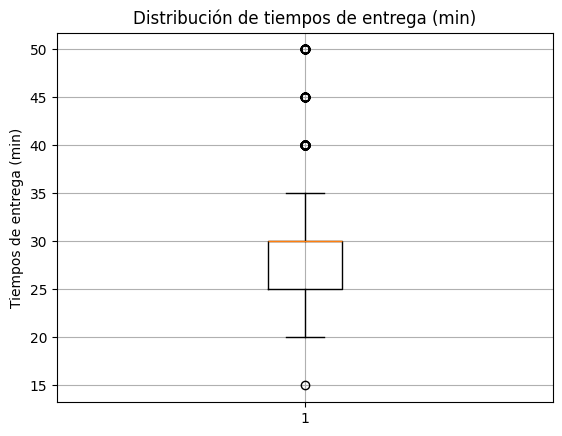

In [14]:
import matplotlib.pyplot as plt
plt.boxplot(pizza_data['Delivery Duration (min)'])
plt.title('Distribución de tiempos de entrega (min)')
plt.ylabel('Tiempos de entrega (min)')
plt.grid()
plt.show()

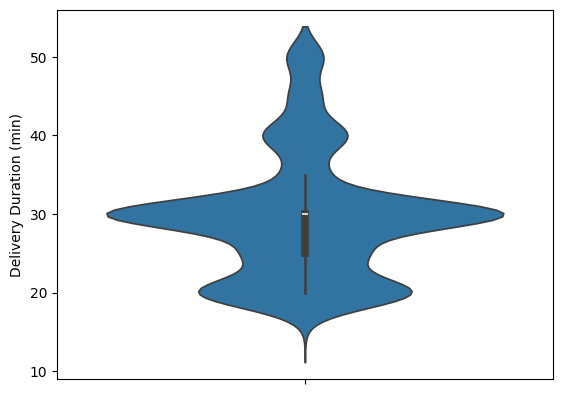

In [15]:
import seaborn as sns
sns.violinplot(pizza_data['Delivery Duration (min)'])
plt.show()

In [16]:
pizza_data['Order ID'].duplicated().sum()
pizza_data['Order ID'].drop_duplicates()

0        ORD001
1        ORD002
2        ORD003
3        ORD004
4        ORD005
         ...   
999     ORD1001
1000    ORD1002
1001    ORD1003
1002    ORD1004
1003    ORD1005
Name: Order ID, Length: 1004, dtype: str

In [17]:
pizza_data.loc['Marco’s Pizza','Restaurant Name'] = "Marco's Pizza"
pizza_data['Restaurant Name'] = pizza_data['Restaurant Name'].str.replace('Marco’s Pizza', "Marco's Pizza")

In [18]:
data_barras = pd.DataFrame(pizza_data['Restaurant Name'].value_counts())
data_barras

,count
Restaurant Name,
Domino's,212
Papa John's,204
Little Caesars,199
Marco's Pizza,196
Pizza Hut,194


In [19]:
duracion_promedio = pizza_data.groupby('Restaurant Name')['Delivery Duration (min)'].mean()
duracion_promedio = duracion_promedio.sort_values()

In [20]:
duracion_promedio

Restaurant Name
Papa John's       28.186275
Little Caesars    28.844221
Pizza Hut         29.948454
Marco's Pizza     30.230769
Domino's          30.259434
Name: Delivery Duration (min), dtype: float64

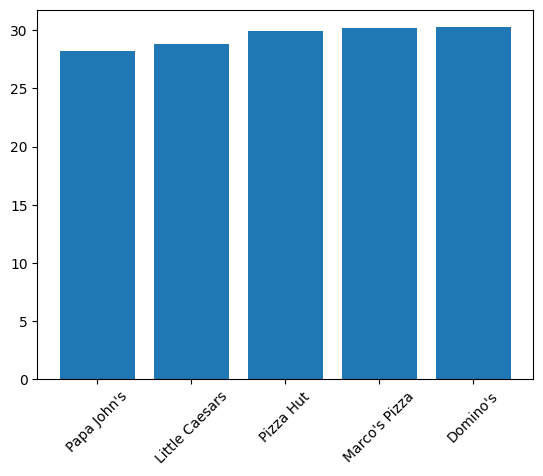

In [21]:
plt.bar(duracion_promedio.index, duracion_promedio.values)
plt.xticks(rotation=45)
plt.show()

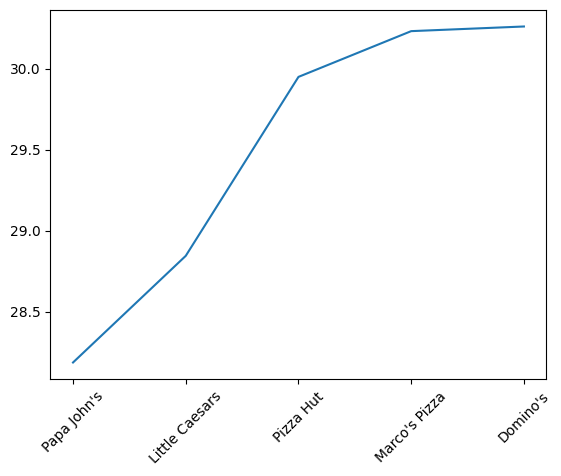

In [22]:
plt.plot(duracion_promedio.index, duracion_promedio.values)
plt.xticks(rotation=45)
plt.show()

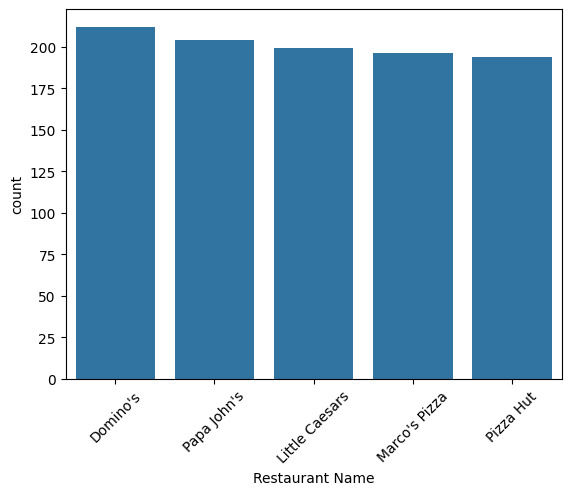

In [23]:
sns.barplot(data_barras, x=data_barras.index, y='count')
plt.xticks(rotation=45)
plt.show()